<a href="https://colab.research.google.com/github/dscamacho333/Data_Science_Course/blob/main/Final_Store_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [19]:
pd.options.display.float_format = '{:,.2f}'.format

In [3]:
store_one_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
store_two_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
store_three_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
store_four_url : str = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

In [4]:
store_one_dataframe : pd.DataFrame = pd.read_csv(
    store_one_url,
    sep=','
)
store_two_dataframe : pd.DataFrame = pd.read_csv(
    store_two_url,
    sep=','
)
store_three_dataframe : pd.DataFrame = pd.read_csv(
    store_three_url,
    sep=','
)
store_four_dataframe : pd.DataFrame = pd.read_csv(
    store_four_url,
    sep=','
)

In [5]:
store_one_dataframe['Tienda'] = 'Store 01'
store_two_dataframe['Tienda'] = 'Store 02'
store_three_dataframe['Tienda'] = 'Store 03'
store_four_dataframe['Tienda'] = 'Store 04'

In [6]:
stores : pd.DataFrame = pd.concat(
    [
        store_one_dataframe,
        store_two_dataframe,
        store_three_dataframe,
        store_four_dataframe
    ],
    ignore_index=True
)

In [7]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                9435 non-null   object 
 1   Categoría del Producto  9435 non-null   object 
 2   Precio                  9435 non-null   float64
 3   Costo de envío          9435 non-null   float64
 4   Fecha de Compra         9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Lugar de Compra         9435 non-null   object 
 7   Calificación            9435 non-null   int64  
 8   Método de pago          9435 non-null   object 
 9   Cantidad de cuotas      9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Tienda                  9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB


## Ingreso total por cada tienda

In [23]:
income_by_store : pd.Series = (
    stores
    .groupby('Tienda')['Precio']
    .sum()
    .round(2)
)

In [24]:
income_by_store

,Precio
Tienda,
Store 01,"1,150,880,400.00"
Store 02,"1,116,343,500.00"
Store 03,"1,098,019,600.00"
Store 04,"1,038,375,700.00"


In [47]:
from matplotlib.axes import Axes
def create_graph(

    object_to_graph,
    graph_type : str,
    title : str,
    x_label : str,
    y_label: str

) -> Axes:

  plt.figure()
  ax = object_to_graph.plot(
      kind=graph_type
  )
  ax.set_title(title)
  ax.set_xlabel(x_label)
  ax.set_ylabel(y_label)

  return ax

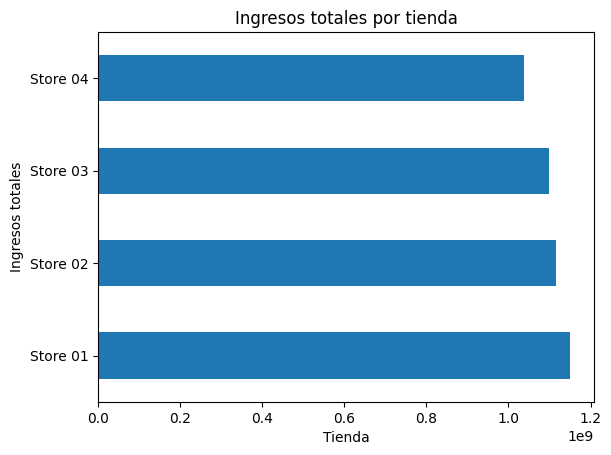

In [53]:
income_by_store_graph : Axes = create_graph(
    income_by_store,
    'barh',
    'Ingresos totales por tienda',
    'Tienda',
    'Ingresos totales'
)

## Ventas por categoría

In [95]:
category_sales = (
    stores
    .groupby(
        [
            'Tienda',
            'Categoría del Producto'
        ]
    )['Producto']
    .count()
    .sort_values(ascending=False)
)

In [96]:
category_sales.loc['Store 01']

,Producto
Categoría del Producto,
Muebles,465
Electrónicos,448
Juguetes,324
Electrodomésticos,312
Deportes y diversión,284
Instrumentos musicales,182
Libros,173
Artículos para el hogar,171


In [97]:
category_sales.loc['Store 02']

,Producto
Categoría del Producto,
Muebles,442
Electrónicos,422
Juguetes,313
Electrodomésticos,305
Deportes y diversión,275
Instrumentos musicales,224
Libros,197
Artículos para el hogar,181


In [98]:
category_sales.loc['Store 03']

,Producto
Categoría del Producto,
Muebles,499
Electrónicos,451
Juguetes,315
Electrodomésticos,278
Deportes y diversión,277
Libros,185
Artículos para el hogar,177
Instrumentos musicales,177


In [99]:
category_sales.loc['Store 04']

,Producto
Categoría del Producto,
Muebles,480
Electrónicos,451
Juguetes,338
Deportes y diversión,277
Electrodomésticos,254
Artículos para el hogar,201
Libros,187
Instrumentos musicales,170


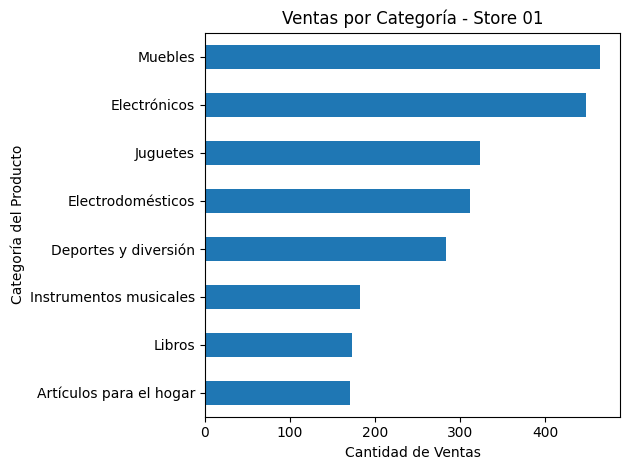

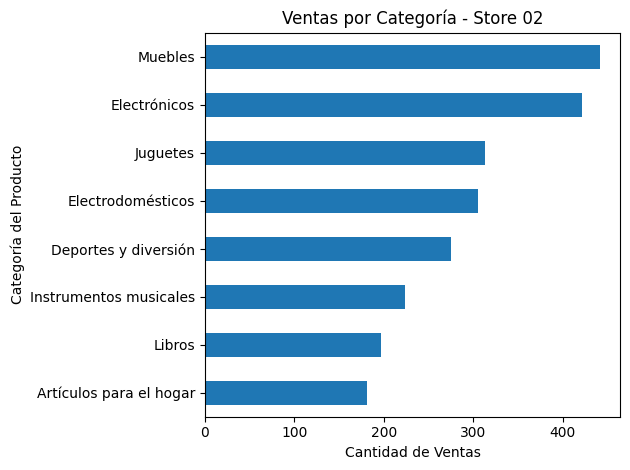

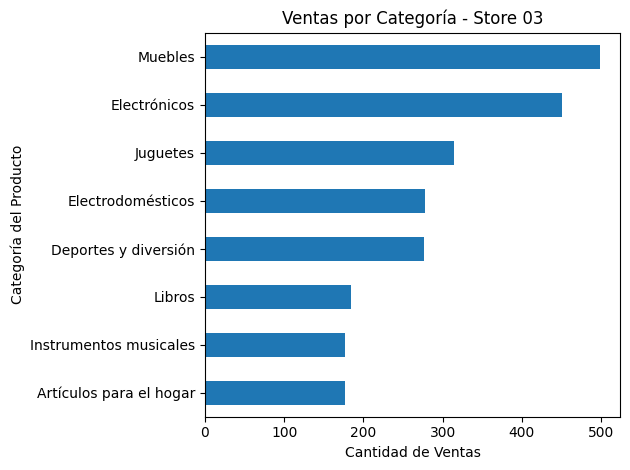

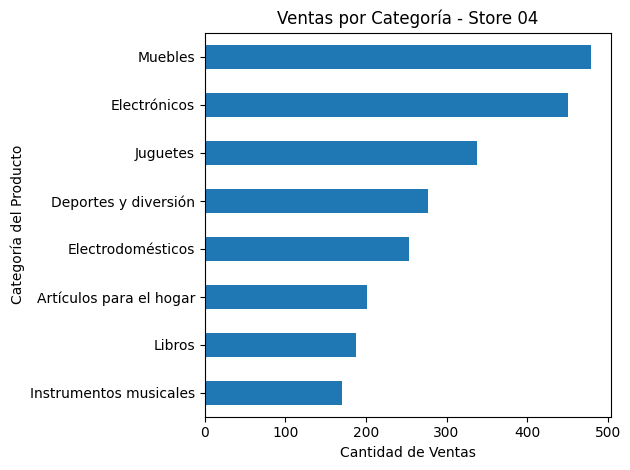

In [105]:
for i in range(1, 5):

    ax = create_graph(
        category_sales.loc[f'Store 0{i}'].sort_values(ascending=True),
        'barh',
        f'Ventas por Categoría - Store 0{i}',
        'Cantidad de Ventas',
        'Categoría del Producto'
    )

    plt.tight_layout()
    plt.show()
